In [127]:
# =========================================================
# IMPORT LIBRARY
# =========================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

from statsmodels.tsa.holtwinters import ExponentialSmoothing



In [128]:
# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_excel(
    "Data IKM Magang.xlsx"
)

In [129]:
# =========================================================
# PREPROCESSING
# =========================================================

df['IKM Konversi'] = (
    df['IKM Konversi']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df['Tanggal'] = pd.to_datetime(
    df['Tanggal']
)

df = df.sort_values(
    'Tanggal'
)

df_ts = df.rename(
    columns={
        'Tanggal':'ds',
        'IKM Konversi':'y'
    }
)

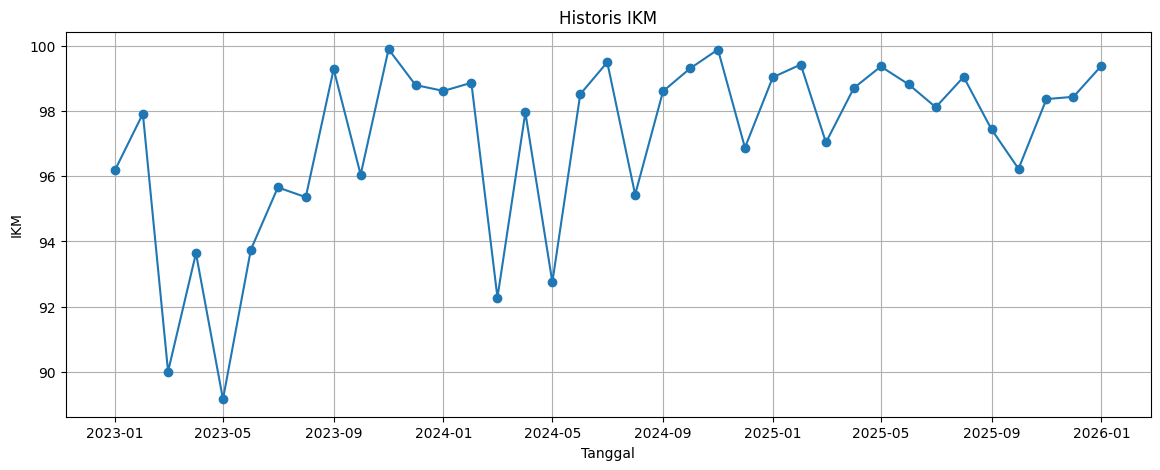

In [130]:
# =========================================================
# VISUALISASI DATA
# =========================================================

plt.figure(figsize=(14,5))

plt.plot(
    df_ts['ds'],
    df_ts['y'],
    marker='o'
)

plt.title(
    'Historis IKM'
)

plt.xlabel('Tanggal')
plt.ylabel('IKM')

plt.grid(True)

plt.show()

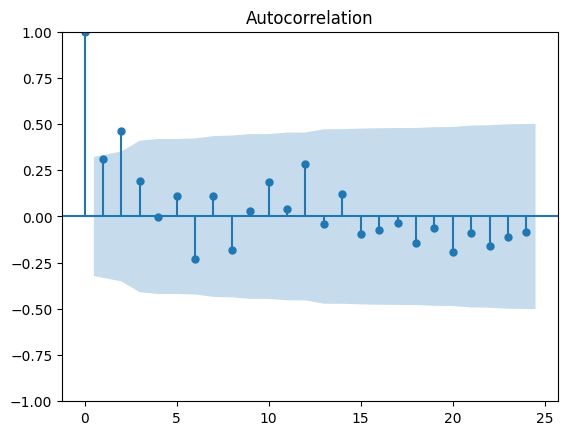

    Lag       ACF
0     0  1.000000
1     1  0.309024
2     2  0.463156
3     3  0.192747
4     4 -0.005248
5     5  0.111438
6     6 -0.228569
7     7  0.109563
8     8 -0.181464
9     9  0.031658
10   10  0.186014
11   11  0.037953
12   12  0.282040
13   13 -0.041819
14   14  0.120866
15   15 -0.092886
16   16 -0.074589
17   17 -0.033467
18   18 -0.143005
19   19 -0.061810
20   20 -0.190700
21   21 -0.090774
22   22 -0.159570
23   23 -0.109932
24   24 -0.084525


In [131]:
# =========================================================
# ANALISIS ACF
# =========================================================

plot_acf(
    df_ts['y'],
    lags=24
)

plt.show()

acf_values = acf(
    df_ts['y'],
    nlags=24
)

acf_df = pd.DataFrame({
    'Lag': range(len(acf_values)),
    'ACF': acf_values
})

print(acf_df)


In [132]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

train_size = int(
    len(df_ts) * 0.8
)

train = df_ts.iloc[
    :train_size
]

test = df_ts.iloc[
    train_size:
]

print(
    "Train :",
    len(train)
)

print(
    "Test :",
    len(test)
)


Train : 29
Test : 8


In [133]:
# =========================================================
# DOUBLE EXPONENTIAL SMOOTHING (DES)
# =========================================================

des_model = ExponentialSmoothing(
    train['y'],
    trend='add'
).fit()

des_pred = des_model.forecast(
    len(test)
)

In [134]:
# =========================================================
# HOLT WINTERS
# =========================================================

hw_model = ExponentialSmoothing(
    train['y'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

hw_pred = hw_model.forecast(
    len(test)
)

In [135]:
# =========================================================
# FUNGSI EVALUASI
# =========================================================

def evaluate(
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = np.mean(
        np.abs(
            (y_true - y_pred)
            / y_true
        )
    ) * 100

    return mae, rmse, mape


In [136]:
# =========================================================
# EVALUASI MODEL
# =========================================================

hasil = []

for nama, prediksi in {

    'DES': des_pred,
    'HoltWinters': hw_pred

}.items():

    mae, rmse, mape = evaluate(
        test['y'],
        prediksi
    )

    hasil.append([
        nama,
        mae,
        rmse,
        mape
    ])

hasil_model = pd.DataFrame(
    hasil,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'MAPE'
    ]
)

hasil_model = hasil_model.sort_values(
    'MAPE'
)

print("\nHASIL EVALUASI MODEL")
print(hasil_model)



HASIL EVALUASI MODEL
         Model       MAE      RMSE      MAPE
0          DES  1.956891  2.198415  2.001258
1  HoltWinters  3.115600  3.574459  3.183126


In [137]:
# =========================================================
# MODEL TERBAIK
# =========================================================

best_model = (
    hasil_model
    .iloc[0]['Model']
)

print(
    "Model Terbaik :",
    best_model
)

Model Terbaik : DES


In [138]:
# =========================================================
# TRAIN ULANG MODEL TERBAIK
# =========================================================

if best_model == 'DES':

    final_model = (
        ExponentialSmoothing(
            df_ts['y'],
            trend='add'
        )
        .fit()
    )

else:

    final_model = (
        ExponentialSmoothing(
            df_ts['y'],
            trend='add',
            seasonal='add',
            seasonal_periods=12
        )
        .fit()
    )

In [139]:
# =========================================================
# FITTING HISTORIS
# =========================================================

historical_fit = pd.DataFrame({

    'Tanggal':
        df_ts['ds'],

    'IKM Aktual':
        df_ts['y'],

    'Fitting':
        final_model.fittedvalues

})

In [140]:
# =========================================================
# FORECAST 12 BULAN
# =========================================================

forecast_12 = final_model.forecast(
    12
)

future_dates = pd.date_range(
    start=df_ts['ds'].max()
          + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

forecast_df = pd.DataFrame({

    'Tanggal':
        future_dates,

    'Forecast':
        np.clip(
            forecast_12.values,
            None,
            100
        )

})

print( forecast_df )

      Tanggal    Forecast
0  2026-02-01   99.532793
1  2026-03-01   99.659255
2  2026-04-01   99.785718
3  2026-05-01   99.912181
4  2026-06-01  100.000000
5  2026-07-01  100.000000
6  2026-08-01  100.000000
7  2026-09-01  100.000000
8  2026-10-01  100.000000
9  2026-11-01  100.000000
10 2026-12-01  100.000000
11 2027-01-01  100.000000


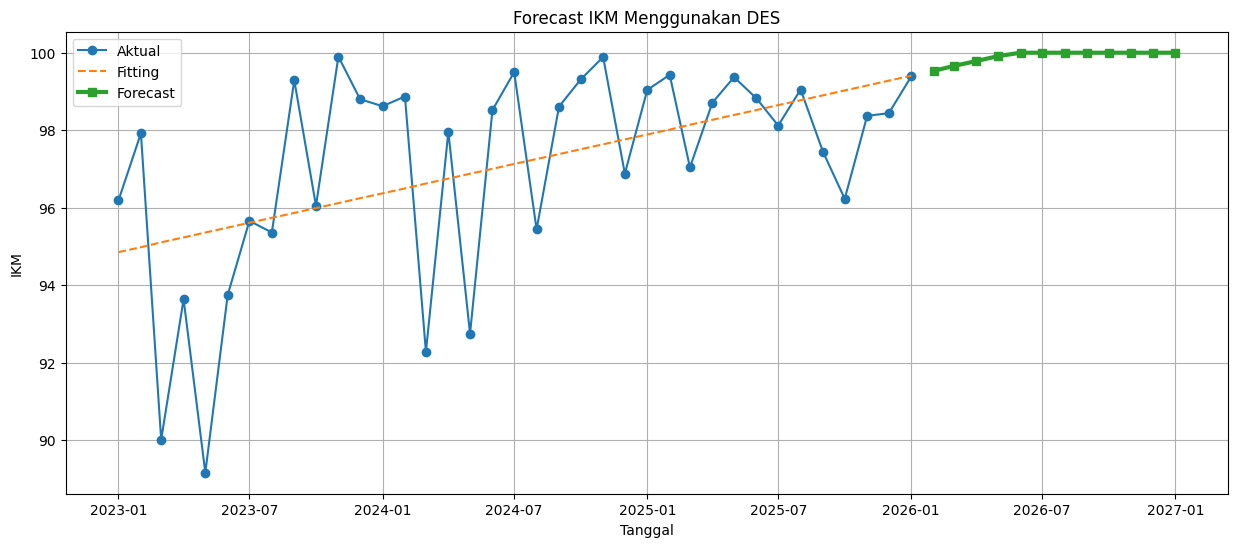

In [141]:
# =========================================================
# VISUALISASI HISTORIS + FORECAST
# =========================================================

plt.figure(figsize=(15,6))

plt.plot(
    historical_fit['Tanggal'],
    historical_fit['IKM Aktual'],
    marker='o',
    label='Aktual'
)

plt.plot(
    historical_fit['Tanggal'],
    historical_fit['Fitting'],
    linestyle='--',
    label='Fitting'
)

plt.plot(
    forecast_df['Tanggal'],
    forecast_df['Forecast'],
    marker='s',
    linewidth=3,
    label='Forecast'
)

plt.title(
    f'Forecast IKM Menggunakan {best_model}'
)

plt.xlabel('Tanggal')
plt.ylabel('IKM')

plt.legend()

plt.grid(True)

plt.show()

In [142]:
# =========================================================
# DASHBOARD
# =========================================================

dashboard_historis = pd.DataFrame({

    'Tanggal':
        historical_fit['Tanggal'],

    'IKM Konversi':
        historical_fit['IKM Aktual'],

    'Prediksi':
        historical_fit['Fitting'],

    'Forecast':
        None
})

dashboard_forecast = pd.DataFrame({

    'Tanggal':
        forecast_df['Tanggal'],

    'IKM Konversi':
        None,

    'Prediksi':
        None,

    'Forecast':
        forecast_df['Forecast']
})

dashboard_final = pd.concat(
    [
        dashboard_historis,
        dashboard_forecast
    ],
    ignore_index=True
)

print(
    dashboard_final
)

      Tanggal  IKM Konversi   Prediksi    Forecast
0  2023-01-01         96.19  94.853670         NaN
1  2023-02-01         97.92  94.980132         NaN
2  2023-03-01         90.01  95.106595         NaN
3  2023-04-01         93.64  95.233058         NaN
4  2023-05-01         89.16  95.359521         NaN
5  2023-06-01         93.75  95.485983         NaN
6  2023-07-01         95.66  95.612446         NaN
7  2023-08-01         95.36  95.738909         NaN
8  2023-09-01         99.29  95.865372         NaN
9  2023-10-01         96.05  95.991835         NaN
10 2023-11-01         99.90  96.118297         NaN
11 2023-12-01         98.80  96.244760         NaN
12 2024-01-01         98.62  96.371223         NaN
13 2024-02-01         98.87  96.497686         NaN
14 2024-03-01         92.28  96.624149         NaN
15 2024-04-01         97.96  96.750611         NaN
16 2024-05-01         92.75  96.877074         NaN
17 2024-06-01         98.52  97.003537         NaN
18 2024-07-01         99.50  97

In [143]:
# =========================================================
# SIMPAN HASIL KE EXCEL
# =========================================================

dashboard_final.to_excel(
    "Forecast_IKM.xlsx",
    index=False
)

print(
    "File Forecast_IKM.xlsx berhasil disimpan"
)

File Forecast_IKM.xlsx berhasil disimpan
